# Notebook 08b - MVP 4 Ablation B: Entropy-Weight Sweep (lambda_ent = 0.01, 10 epochs)

**This is a single-variable ablation of NB 08.** Two HPARAMS changed:
- `entropy_weight = 0.01` (NB 08 baseline: 0.05)
- `epochs = 10` (NB 08 baseline: 5)

All other architectural decisions, data, splits, loss formulation, optimiser, seed,
and frozen-encoder lineage are byte-identical to NB 08. Output paths point to
`models/mvp4_gated_fusion_ent01[_best]/` and `outputs/nb08b_*.png` so no existing NB 08
artefacts are touched.

**Hypothesis under test.** NB 08 finding 4 (Phase 2 report §15.10) observed val T1 F1 drifting
from 0.7000 (epoch 3) to 0.6926 (epoch 5) as mean gate entropy approached log(3). The
lambda_ent = 0.05 setting may be over-regularising — pushing the gate toward uniformity faster
than per-sample evidence supports. This ablation tests whether a 5x weaker entropy push
(lambda_ent = 0.01) with a 2x longer epoch budget (10 vs 5) lets the gate retain useful per-sample
selectivity while still preventing collapse, and whether val T1 F1 stabilises or recovers.

## What stays the same as NB 08

1. Hybrid fusion: cross-modal attention (image queries text tokens, 8 heads) + softmax gate over 3.
2. Gate computation `softmax(Linear(1568 -> 3))`.
3. Sign on entropy regulariser is negative (`L_total = L_task - lambda_ent * H(g)`).
4. Freezing: text encoder + Run-D LoRA frozen, CLIP + MVP-2 LoRA + projections frozen,
   Branch C MLP fresh init (NOT loaded from MVP 3).
5. Gate-collapse diagnostic: warn if `H_mean < 0.5`.
6. T2 loss masked to `t2_valid=True` rows only.
7. Task weighting: `0.7 * L_T1 + 0.3 * L_T2 - lambda_ent * H(g)`.


**Purpose.** Test the central hypothesis of the thesis: a gated cross-modal attention fusion module, regularised with entropy on the gate distribution, breaks the ~0.74 AUC ceiling set by the deliberately-naive ladder of MVP 1-3. The hybrid mechanism - image attends to text tokens, then a per-sample softmax gate re-weights the three branches - gives the network the option to ignore an unreliable modality on a sample-by-sample basis. Entropy regularisation prevents the gate from collapsing onto a single modality during training, which is the documented failure mode of unregularised gated fusion.

**Why this is the load-bearing notebook.** MVP 1 (text only), MVP 2 (text+image concat), and MVP 3 (text+image+structured concat) all sit at AUC ~= 0.74. Adding modalities under naive concat has not paid off - it has slightly *increased* FPR. If MVP 4 also lands at 0.74 with no FPR reduction, the multimodal claim of the thesis is unsupported and the project's contribution narrows to the bias-and-uncertainty work in MVP 5. If MVP 4 lifts AUC above 0.74 *and* reduces FPR below MVP 2's 0.3041, the gated-attention contribution is confirmed.

## Seven locked decisions

1. **Hybrid fusion** - cross-modal attention (image queries text tokens) *plus* sample-level scalar gate over three branches. *Refs: MLCA (2025), GatedCLIP (2025).*
2. **Gate computation** - `g = softmax(Linear(1568 -> 3))`, where 1568 = 768 (text CLS) + 768 (cross-attended image) + 32 (structured). *Ref: AECF (arXiv 2505.15417).*
3. **Entropy regularisation** - `L_total = L_task - 0.05 * H(gates)` where `H(p) = -sum_m p_m log p_m`, computed per sample and averaged across the batch. Sign is **negative** because we *maximise* entropy to discourage collapse. *Refs: AECF (arXiv 2505.15417), MAGNET (arXiv 2602.20723).*
4. **Freezing strategy.**
   - Text encoder + LoRA (Run D, rank 32): **frozen** (carried over from MVP 1 / MVP 2 / MVP 3 lineage).
   - CLIP vision + LoRA (rank 16) + 768->512 projection + 512->768 image projection: **frozen** (loaded from MVP 2 best).
   - Branch C MLP (9 -> 32): **trainable, fresh init** - NOT loaded from MVP 3, because its weights were learnt under a different (naive-concat 1568-d) fusion regime.
   - Cross-attention + post-attention LayerNorm: **trainable, new**.
   - Gate linear (1568 -> 3): **trainable, new**.
   - Three 256-d projection layers (text, image, struct -> 256): **trainable, new**.
   - T1 head (256 -> 128 -> 1) and T2 head (256 -> 128 -> 6): **trainable, fresh init** (input dim changed from 1568 in MVP 2/3 to 256 here).
5. **Gate-collapse diagnostic** - log per-epoch mean gate entropy on train and val. Warn if `H_mean < 0.5`. Max entropy for 3 branches is `log(3) ~= 1.099`; an `H` of 0.5 means the dominant branch is taking ~80% of the mass on average.
6. **T2 loss masked to `t2_valid = True`** rows only (3-way disagreement rows excluded from T2 supervision, carried over from MVP 2 / MVP 3).
7. **Loss weighting** - `0.7 * L_T1 + 0.3 * L_T2 - 0.05 * H(gates)`.

## Baselines to beat (balanced 50/50 test, threshold 0.5)

| Run                              |   AUC  |   F1m  |   FPR  |
|----------------------------------|-------:|-------:|-------:|
| MVP 1 (text-only, Run D)         | 0.7431 | 0.6855 | 0.2667 |
| MVP 2 (T + I naive concat)       | 0.7411 | 0.6892 | 0.3041 |
| MVP 3 (T + I + S naive concat)   | 0.7406 | 0.6905 | 0.3361 |
| **MVP 4 target**                 | **> 0.7431** | **>= 0.69** | **< 0.3041** |

**Success criterion.** Test AUC strictly above MVP 1 (the strongest current baseline) *and* FPR strictly below MVP 2 - i.e. gated attention must both add signal and reduce false positives. If only one of the two improves, report honestly; both improving is the thesis's load-bearing claim.

## Cell map

| Cell | Purpose |
|---|---|
| 2 | Imports, seeds, device, HPARAMS, pre-training GPU-memory check (>12 GB allocated -> warn). |
| 3 | Load labels + structured CSVs, merge on `tweet_id`, attach official splits, per-split T1/T2/`t2_valid` distributions. |
| 4 | Load `standardisation_stats.json` from MVP 3 (do **not** recompute). Fall back to train-only recompute with a warning if missing. |
| 5 | Image audit - drop rows whose image is not on disk; print final per-split sizes. |
| 6 | `MMHS150KMultimodalDataset` + DataLoaders (train/val/test). |
| 7 | Losses: Focal BCE (T1, pos_weight from train), Focal CE (T2, class weights, `t2_valid` mask), gate-entropy regulariser, combined-loss helper. |
| 8 | `MVP4GatedFusion` model class - frozen MVP 2 surface + fresh Branch C + new cross-attn + new gate + new projections + fresh heads + freeze-surface assertions. |
| 9 | Forward sanity check on a single batch - confirm `(logits_t1, logits_t2, gates)` shapes are `(B, 1)`, `(B, 6)`, `(B, 3)`. |
| 10 | AdamW + 10% warmup -> cosine schedule + fp16 autocast + GradScaler + grad-accum 4. |
| 11 | Training loop (5 epochs) with per-epoch train/val gate-entropy and per-branch gate-weight diagnostics. Save best by `val_t1_auc`. Collapse warning if `H < 0.5`. GPU-mem warning if `> 14 GB` allocated. |
| 12 | Reload best, test eval - T1 metrics (AUC/F1/P/R/FPR/CM at 0.5), T2 metrics (macro F1 + per-class, valid-only), gate stats, save 4 charts + per-sample `test_gates.npy`. |
| 13 | Recalibrated T1 metrics (Bayes shift to 22% hate prior, F1-optimised threshold on recalibrated val). |
| 14 | Final comparison vs MVP 1 / 2 / 3, verdict, save `hparams.json` + `training_history.json` + `final_gate_stats.json` + copy of `standardisation_stats.json`.


In [1]:
import os, sys, json, random, gc, time, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              classification_report)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoTokenizer, AutoModel,
                          CLIPVisionModel, CLIPModel, CLIPImageProcessor,
                          get_cosine_schedule_with_warmup)
from peft import PeftModel

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
if torch.cuda.is_available():
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    alloc_gb = torch.cuda.memory_allocated() / 1024**3
    resv_gb  = torch.cuda.memory_reserved() / 1024**3
    print(f'gpu total: {total_gb:.2f} GB | allocated now: {alloc_gb:.2f} GB | reserved now: {resv_gb:.2f} GB')
    if alloc_gb > 12.0:
        print(f'WARNING: GPU memory already at {alloc_gb:.2f} GB before training - free memory or restart kernel before continuing.')

HPARAMS = dict(
    max_len=128,
    image_size=224,
    batch_size=16,
    epochs=10,
    # all trainable groups share lr; spec calls for one AdamW group at 1e-3
    struct_lr=1e-3,
    gate_lr=1e-3,
    crossattn_lr=1e-3,
    proj_lr=1e-3,
    head_lr=1e-3,
    lr=1e-3,
    warmup_ratio=0.1,
    gamma=2.0,
    grad_accum_steps=4,
    threshold=0.5,
    t1_weight=0.7,
    t2_weight=0.3,
    entropy_weight=0.01,
    collapse_threshold=0.5,
    gpu_warn_gb=14.0,
    weight_decay=0.01,
    dropout=0.1,
    struct_hidden=32,
    fusion_dim=256,
    n_struct_features=9,
    crossattn_heads=8,
    crossattn_dropout=0.1,
    text_base='cardiffnlp/twitter-roberta-base-2022-154m',
    text_adapter='models/roberta_mvp1_d',
    clip_model='openai/clip-vit-base-patch16',
    mvp2_best_dir='models/mvp2_naive_concat_best',
    mvp3_best_dir='models/mvp3_three_branch_best',
    prior_hate=0.2468,
    prior_nothate=0.7532,
    n_t2_classes=6,
    seed=SEED,
)
for k, v in HPARAMS.items():
    print(f'  {k}: {v}')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
LABELS_CSV = ROOT / 'data' / 'processed' / 'labels_parsed.csv'
STRUCT_CSV = ROOT / 'data' / 'processed' / 'structured_features.csv'
SPLITS_DIR = ROOT / 'data' / 'MMHS150K' / 'splits'
IMG_DIR    = ROOT / 'data' / 'MMHS150K' / 'img_resized'
TEXT_ADAPTER_DIR = ROOT / HPARAMS['text_adapter']
MVP2_BEST_DIR    = ROOT / HPARAMS['mvp2_best_dir']
MVP3_BEST_DIR    = ROOT / HPARAMS['mvp3_best_dir']
OUT_DIR   = ROOT / 'outputs'
MODEL_DIR = ROOT / 'models' / 'mvp4_gated_fusion_ent01'
BEST_DIR  = ROOT / 'models' / 'mvp4_gated_fusion_ent01_best'
for d in [OUT_DIR, MODEL_DIR, BEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
for p, name in [(LABELS_CSV, 'LABELS_CSV'), (STRUCT_CSV, 'STRUCT_CSV'),
                 (SPLITS_DIR, 'SPLITS_DIR'), (IMG_DIR, 'IMG_DIR'),
                 (TEXT_ADAPTER_DIR, 'TEXT_ADAPTER_DIR'),
                 (MVP2_BEST_DIR, 'MVP2_BEST_DIR'),
                 (MVP3_BEST_DIR, 'MVP3_BEST_DIR')]:
    print(f'  {name:<18} exists={p.exists()}  -> {p}')


device: cuda | NVIDIA L4
gpu total: 22.03 GB | allocated now: 0.00 GB | reserved now: 0.00 GB
  max_len: 128
  image_size: 224
  batch_size: 16
  epochs: 10
  struct_lr: 0.001
  gate_lr: 0.001
  crossattn_lr: 0.001
  proj_lr: 0.001
  head_lr: 0.001
  lr: 0.001
  warmup_ratio: 0.1
  gamma: 2.0
  grad_accum_steps: 4
  threshold: 0.5
  t1_weight: 0.7
  t2_weight: 0.3
  entropy_weight: 0.01
  collapse_threshold: 0.5
  gpu_warn_gb: 14.0
  weight_decay: 0.01
  dropout: 0.1
  struct_hidden: 32
  fusion_dim: 256
  n_struct_features: 9
  crossattn_heads: 8
  crossattn_dropout: 0.1
  text_base: cardiffnlp/twitter-roberta-base-2022-154m
  text_adapter: models/roberta_mvp1_d
  clip_model: openai/clip-vit-base-patch16
  mvp2_best_dir: models/mvp2_naive_concat_best
  mvp3_best_dir: models/mvp3_three_branch_best
  prior_hate: 0.2468
  prior_nothate: 0.7532
  n_t2_classes: 6
  seed: 42
ROOT: /teamspace/studios/this_studio/HateFusion
  LABELS_CSV         exists=True  -> /teamspace/studios/this_studio/H

In [2]:
# Load labels + structured features, merge on tweet_id, attach official splits.
df_lab = pd.read_csv(LABELS_CSV)
df_str = pd.read_csv(STRUCT_CSV)
print('labels raw shape :', df_lab.shape, '| nulls:', df_lab.isna().sum().to_dict())
print('struct raw shape :', df_str.shape, '| nulls:', df_str.isna().sum().to_dict())

# Canonical feature order (positional, deterministic regardless of CSV column order).
# Mirrors MVP 3 / standardisation_stats.json exactly.
FEATURE_ORDER = [
    'vader_neg', 'vader_neu', 'n_emoji', 'hate_keyword_count',
    'ocr_present', 'profanity_count', 'n_hashtags', 'ocr_len', 'n_mentions',
]
assert len(FEATURE_ORDER) == 9
assert set(FEATURE_ORDER).issubset(df_str.columns), \
    f'missing struct cols: {set(FEATURE_ORDER) - set(df_str.columns)}'

df = df_lab.merge(df_str[['tweet_id'] + FEATURE_ORDER], on='tweet_id', how='inner')
print('post-merge shape :', df.shape, '| nulls:', df.isna().sum().to_dict())
assert df[FEATURE_ORDER].isna().sum().sum() == 0, 'structured features have nulls - investigate before training'

def read_ids(p):
    return set(int(line.strip()) for line in open(p) if line.strip())

splits = {
    'train': read_ids(SPLITS_DIR / 'train_ids.txt'),
    'val':   read_ids(SPLITS_DIR / 'val_ids.txt'),
    'test':  read_ids(SPLITS_DIR / 'test_ids.txt'),
}
print(f'split txt sizes: train={len(splits["train"])} val={len(splits["val"])} test={len(splits["test"])}')

def assign_split(tid):
    for name, s in splits.items():
        if tid in s:
            return name
    return None
df['split'] = df['tweet_id'].apply(assign_split)
n_no_split = int(df['split'].isna().sum())
print(f'rows with no split assigned: {n_no_split} (should be 0 if GT and splits agree)')
df = df[df['split'].notna()].reset_index(drop=True)

for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s]
    t1_dist = sub['T1'].value_counts().to_dict()
    t2_dist = sub['T2'].value_counts(dropna=False).to_dict()
    t2v = int(sub['t2_valid'].sum())
    print(f'  {s:<6} n={len(sub):>7}  T1={t1_dist}  t2_valid={t2v}/{len(sub)}')
    print(f'         T2 counts (incl NaN): {t2_dist}')

print('\nfinal merged shape:', df.shape, '| nulls per col:', df.isna().sum().to_dict())


labels raw shape : (149819, 10) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0}
struct raw shape : (149819, 10) | nulls: {'tweet_id': 0, 'vader_neg': 0, 'vader_neu': 0, 'n_emoji': 0, 'ocr_present': 0, 'n_hashtags': 0, 'ocr_len': 0, 'hate_keyword_count': 0, 'profanity_count': 0, 'n_mentions': 0}
post-merge shape : (149819, 19) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'vader_neg': 0, 'vader_neu': 0, 'n_emoji': 0, 'hate_keyword_count': 0, 'ocr_present': 0, 'profanity_count': 0, 'n_hashtags': 0, 'ocr_len': 0, 'n_mentions': 0}
split txt sizes: train=134823 val=5000 test=10000


rows with no split assigned: 0 (should be 0 if GT and splits agree)
  train  n= 134820  T1={0: 105344, 1: 29476}  t2_valid=125501/134820
         T2 counts (incl NaN): {0.0: 105344, 1.0: 9505, nan: 9319, 5.0: 4645, 3.0: 3087, 2.0: 2790, 4.0: 130}
  val    n=   4999  T1={1: 2500, 0: 2499}  t2_valid=4197/4999
         T2 counts (incl NaN): {0.0: 2499, 1.0: 809, nan: 802, 5.0: 386, 3.0: 253, 2.0: 241, 4.0: 9}
  test   n=  10000  T1={1: 5001, 0: 4999}  t2_valid=8411/10000
         T2 counts (incl NaN): {0.0: 4999, 1.0: 1613, nan: 1589, 5.0: 780, 3.0: 531, 2.0: 464, 4.0: 24}

final merged shape: (149819, 20) | nulls per col: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'vader_neg': 0, 'vader_neu': 0, 'n_emoji': 0, 'hate_keyword_count': 0, 'ocr_present': 0, 'profanity_count': 0, 'n_hashtags': 0, 'ocr_len': 0, 'n_mentions': 0, 'split': 0}


In [3]:
# Load standardisation stats from MVP 3 (TRAIN-only z-score / clip statistics).
# Locked decision: do NOT recompute. If the file is missing we fall back to a recompute
# from train and print an explicit warning so the run isn't silently inconsistent with MVP 3.
stats_path = MVP3_BEST_DIR / 'standardisation_stats.json'
if stats_path.exists():
    with open(stats_path, 'r') as f:
        STRUCT_STATS = json.load(f)
    print(f'loaded MVP 3 standardisation stats from {stats_path}')
else:
    print(f'WARNING: {stats_path} missing - recomputing from train split. This run will not be statistically identical to MVP 3.')
    BINARY_FEATURES = ['ocr_present']
    NON_BINARY_FEATURES = [c for c in FEATURE_ORDER if c not in BINARY_FEATURES]
    train_mask = (df['split'] == 'train')
    train_struct = df.loc[train_mask, FEATURE_ORDER].copy()
    ocr_len_clip = float(train_struct['ocr_len'].quantile(0.99))
    train_struct['ocr_len'] = train_struct['ocr_len'].clip(upper=ocr_len_clip)
    feature_means = {c: float(train_struct[c].mean()) for c in NON_BINARY_FEATURES}
    feature_stds  = {c: float(train_struct[c].std(ddof=0) or 1.0) for c in NON_BINARY_FEATURES}
    STRUCT_STATS = {
        'feature_order': FEATURE_ORDER,
        'binary_features': BINARY_FEATURES,
        'non_binary_features': NON_BINARY_FEATURES,
        'ocr_len_clip': ocr_len_clip,
        'ocr_len_clip_percentile': 0.99,
        'feature_means': feature_means,
        'feature_stds':  feature_stds,
    }

assert STRUCT_STATS['feature_order'] == FEATURE_ORDER, \
    f"feature_order mismatch: stats={STRUCT_STATS['feature_order']} expected={FEATURE_ORDER}"

print('\nstandardisation stats in use:')
print(f'  feature_order:     {STRUCT_STATS["feature_order"]}')
print(f'  binary_features:   {STRUCT_STATS["binary_features"]}')
print(f'  ocr_len_clip:      {STRUCT_STATS["ocr_len_clip"]:.2f} (P{int(STRUCT_STATS["ocr_len_clip_percentile"]*100)})')
print('  feature_means:')
for k, v in STRUCT_STATS['feature_means'].items():
    print(f'    {k:<22} mean={v:>12.6f}')
print('  feature_stds:')
for k, v in STRUCT_STATS['feature_stds'].items():
    print(f'    {k:<22} std ={v:>12.6f}')


loaded MVP 3 standardisation stats from /teamspace/studios/this_studio/HateFusion/models/mvp3_three_branch_best/standardisation_stats.json

standardisation stats in use:
  feature_order:     ['vader_neg', 'vader_neu', 'n_emoji', 'hate_keyword_count', 'ocr_present', 'profanity_count', 'n_hashtags', 'ocr_len', 'n_mentions']
  binary_features:   ['ocr_present']
  ocr_len_clip:      389.00 (P99)
  feature_means:
    vader_neg              mean=    0.172504
    vader_neu              mean=    0.729812
    n_emoji                mean=    0.563017
    hate_keyword_count     mean=    0.722356
    profanity_count        mean=    0.915027
    n_hashtags             mean=    0.202403
    ocr_len                mean=   29.380656
    n_mentions             mean=    0.528868
  feature_stds:
    vader_neg              std =    0.186615
    vader_neu              std =    0.206670
    n_emoji                std =    1.561354
    hate_keyword_count     std =    0.484619
    profanity_count        std =

In [4]:
# Image audit - per EDA Q1 all 149,819 GT-referenced images are on disk, this is
# defensive belt-and-braces against any stray missing/corrupt file.
print(f'enumerating .jpg files in {IMG_DIR} ...')
_t = time.time()
available_ids = set()
for p in IMG_DIR.iterdir():
    if p.suffix.lower() == '.jpg':
        try:
            available_ids.add(int(p.stem))
        except ValueError:
            continue
print(f'  scandir done in {time.time()-_t:.1f}s, {len(available_ids):,} .jpg files indexed')

before = len(df)
df['img_exists'] = df['tweet_id'].isin(available_ids)
missing_per_split = df[~df['img_exists']].groupby('split').size().to_dict()
print(f'\nrows with no image on disk (per split): {missing_per_split}')
df = df[df['img_exists']].reset_index(drop=True).drop(columns=['img_exists'])
after = len(df)
print(f'dropped {before - after} rows due to missing images. shape: {df.shape}')

print('\nfinal per-split sizes after image audit:')
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s]
    print(f'  {s:<6} n={len(sub):>7} T1 hate%={sub["T1"].mean()*100:5.2f}% t2_valid={int(sub["t2_valid"].sum())}')
print('final nulls (selected cols):', df[['tweet_id','tweet_text','T1','T2','t2_valid']].isna().sum().to_dict())


enumerating .jpg files in /teamspace/studios/this_studio/HateFusion/data/MMHS150K/img_resized ...


  scandir done in 0.5s, 150,000 .jpg files indexed

rows with no image on disk (per split): {}
dropped 0 rows due to missing images. shape: (149819, 20)

final per-split sizes after image audit:
  train  n= 134820 T1 hate%=21.86% t2_valid=125501
  val    n=   4999 T1 hate%=50.01% t2_valid=4197
  test   n=  10000 T1 hate%=50.01% t2_valid=8411
final nulls (selected cols): {'tweet_id': 0, 'tweet_text': 0, 'T1': 0, 'T2': 11710, 't2_valid': 0}


In [5]:
# Tokeniser, image processor, dataset class with structured features and cross-attention-ready text.
tokenizer = AutoTokenizer.from_pretrained(HPARAMS['text_base'])
image_processor = CLIPImageProcessor.from_pretrained(HPARAMS['clip_model'])
print('tokenizer:', tokenizer.__class__.__name__, '| vocab:', tokenizer.vocab_size)
print('image_processor:', image_processor.__class__.__name__, '| size:', image_processor.size)
print('image_processor mean/std:', image_processor.image_mean, '/', image_processor.image_std)

def apply_struct_transform(df_sub, stats):
    '''Returns (N, 9) float32 array in FEATURE_ORDER, with train stats applied:
    clip ocr_len at P99, z-score the 8 non-binary features, leave ocr_present in {0, 1}.'''
    out = np.zeros((len(df_sub), len(stats['feature_order'])), dtype=np.float32)
    for j, col in enumerate(stats['feature_order']):
        v = df_sub[col].to_numpy(dtype=np.float32)
        if col == 'ocr_len':
            v = np.minimum(v, stats['ocr_len_clip'])
        if col in stats['non_binary_features']:
            mu = stats['feature_means'][col]
            sd = stats['feature_stds'][col]
            v = (v - mu) / sd
        out[:, j] = v
    return out

class MMHS150KMultimodalDataset(Dataset):
    '''Pre-tokenises text once and pre-computes standardised structured features once.
    Loads images lazily per __getitem__. Hashtags/mentions/URLs preserved verbatim
    (no stripping - per project rules they carry signal for the text branch).
    T2 NaN rows are stored with placeholder 0 and masked via t2_valid_mask in the loss.'''
    def __init__(self, sub_df, tok, img_proc, img_dir, max_len, struct_stats):
        texts = sub_df['tweet_text'].astype(str).tolist()
        enc = tok(texts, truncation=True, padding='max_length',
                  max_length=max_len, return_tensors='pt')
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.t1_labels = torch.tensor(sub_df['T1'].to_numpy(dtype=np.float32))
        t2_arr = sub_df['T2'].fillna(0).to_numpy(dtype=np.int64)
        self.t2_labels = torch.tensor(t2_arr, dtype=torch.long)
        self.t2_valid_mask = torch.tensor(
            sub_df['t2_valid'].to_numpy(dtype=np.bool_), dtype=torch.bool)
        self.tweet_ids = sub_df['tweet_id'].to_numpy(dtype=np.int64)
        self.struct_features = torch.tensor(
            apply_struct_transform(sub_df, struct_stats), dtype=torch.float32)
        self.img_dir = Path(img_dir)
        self.img_proc = img_proc
    def __len__(self):
        return self.t1_labels.size(0)
    def __getitem__(self, idx):
        tid = int(self.tweet_ids[idx])
        with Image.open(self.img_dir / f'{tid}.jpg') as im:
            if im.mode != 'RGB':
                im = im.convert('RGB')
            pixel = self.img_proc(im, return_tensors='pt')['pixel_values'].squeeze(0)
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'pixel_values': pixel,
            'structured': self.struct_features[idx],
            't1_label': self.t1_labels[idx],
            't2_label': self.t2_labels[idx],
            't2_valid_mask': self.t2_valid_mask[idx],
            'tweet_id': tid,
        }

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
print(f'split frames: train {train_df.shape} | val {val_df.shape} | test {test_df.shape}')

print('tokenising text + computing structured features (one pass per split)...')
_t = time.time()
train_ds = MMHS150KMultimodalDataset(train_df, tokenizer, image_processor, IMG_DIR, HPARAMS['max_len'], STRUCT_STATS)
val_ds   = MMHS150KMultimodalDataset(val_df,   tokenizer, image_processor, IMG_DIR, HPARAMS['max_len'], STRUCT_STATS)
test_ds  = MMHS150KMultimodalDataset(test_df,  tokenizer, image_processor, IMG_DIR, HPARAMS['max_len'], STRUCT_STATS)
print(f'  done in {time.time()-_t:.1f}s')
print(f'datasets: train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=HPARAMS['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=HPARAMS['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=HPARAMS['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)

_b = train_ds[0]
print(f'sample shapes: input_ids {tuple(_b["input_ids"].shape)}, '
      f'pixel_values {tuple(_b["pixel_values"].shape)}, structured {tuple(_b["structured"].shape)}, '
      f't1 {_b["t1_label"].item()}, t2 {_b["t2_label"].item()}, t2_valid {bool(_b["t2_valid_mask"].item())}')
print(f'structured (post-transform) sample: {_b["structured"].numpy().round(4).tolist()}')


tokenizer: RobertaTokenizer | vocab: 50265
image_processor: CLIPImageProcessor | size: SizeDict(height=None, width=None, longest_edge=None, shortest_edge=224, max_height=None, max_width=None)
image_processor mean/std: (0.48145466, 0.4578275, 0.40821073) / (0.26862954, 0.26130258, 0.27577711)
split frames: train (134820, 20) | val (4999, 20) | test (10000, 20)
tokenising text + computing structured features (one pass per split)...


  done in 22.0s
datasets: train 134820 | val 4999 | test 10000
sample shapes: input_ids (128,), pixel_values (3, 224, 224), structured (9,), t1 1.0, t2 0, t2_valid False
structured (post-transform) sample: [-0.9243999719619751, 1.3072999715805054, -0.36059999465942383, -1.4905999898910522, 1.0, -1.0981999635696411, -0.2563999891281128, -0.16529999673366547, 0.5683000087738037]


In [6]:
# Loss functions: Focal BCE for T1, masked Focal CE for T2, and gate-entropy regulariser.
y_train_t1 = train_df['T1'].to_numpy()
cw_t1 = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train_t1)
pos_weight_value = float(cw_t1[1] / cw_t1[0])
pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
print(f'T1 class weights from TRAIN: nothate={cw_t1[0]:.4f}, hate={cw_t1[1]:.4f}')
print(f'T1 pos_weight (hate/nothate ratio): {pos_weight_value:.4f}')

class FocalBCE(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
    def forward(self, logits, target):
        logits = logits.view(-1)
        target = target.view(-1).float()
        bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
        p = torch.sigmoid(logits)
        pt = p * target + (1.0 - p) * (1.0 - target)
        focal = (1.0 - pt).pow(self.gamma) * bce
        if self.pos_weight is not None:
            w = target * self.pos_weight + (1.0 - target)
            focal = focal * w
        return focal.mean()

criterion_t1 = FocalBCE(gamma=HPARAMS['gamma'], pos_weight=pos_weight)
print(f'criterion_t1: FocalBCE(gamma={HPARAMS["gamma"]}, pos_weight={pos_weight_value:.4f})')

y_train_t2_valid = train_df.loc[train_df['t2_valid'], 'T2'].astype(int).to_numpy()
cw_t2_np = compute_class_weight('balanced',
                                 classes=np.arange(HPARAMS['n_t2_classes']),
                                 y=y_train_t2_valid)
class_weights_t2 = torch.tensor(cw_t2_np, dtype=torch.float32, device=device)
print(f'T2 class weights from TRAIN (t2_valid=True only): {cw_t2_np.round(4).tolist()}')

class FocalCEMasked(nn.Module):
    '''Focal cross-entropy with class weights, masked to valid rows via t2_valid_mask.'''
    def __init__(self, gamma=2.0, class_weights=None):
        super().__init__()
        self.gamma = gamma
        self.class_weights = class_weights
    def forward(self, logits, target, valid_mask):
        if valid_mask.sum() == 0:
            return logits.sum() * 0.0  # no-op contribution, keeps autograd graph
        ce = F.cross_entropy(logits, target, weight=self.class_weights, reduction='none')
        p = F.softmax(logits, dim=-1)
        pt = p.gather(1, target.unsqueeze(1)).squeeze(1).clamp_min(1e-8)
        focal = (1.0 - pt).pow(self.gamma) * ce
        focal = focal * valid_mask.float()
        return focal.sum() / valid_mask.float().sum().clamp_min(1.0)

criterion_t2 = FocalCEMasked(gamma=HPARAMS['gamma'], class_weights=class_weights_t2)
print(f'criterion_t2: FocalCEMasked(gamma={HPARAMS["gamma"]}, class_weights from train t2_valid=True)')

def gate_entropy(gates, eps=1e-8):
    '''Per-sample entropy of the softmax gate, averaged across the batch.
    H(p) = -sum_m p_m log p_m   (computed in fp32 for numerical stability under autocast).'''
    g = gates.float()
    return -(g * torch.log(g + eps)).sum(dim=-1).mean()

def combined_loss(logit_t1, logits_t2, gates, y1, y2, m2, w_t1, w_t2, ent_w):
    '''L_total = w_t1 * L_T1 + w_t2 * L_T2 - ent_w * H(gates).
    The entropy term is SUBTRACTED (we MAXIMISE entropy to prevent gate collapse).
    Returns (total, l_t1, l_t2, H_mean) all as scalar tensors.'''
    l_t1 = criterion_t1(logit_t1, y1)
    l_t2 = criterion_t2(logits_t2, y2, m2)
    H_mean = gate_entropy(gates)
    total = w_t1 * l_t1 + w_t2 * l_t2 - ent_w * H_mean
    return total, l_t1, l_t2, H_mean

print(f'\nloss weights: t1={HPARAMS["t1_weight"]}, t2={HPARAMS["t2_weight"]}, '
      f'entropy={HPARAMS["entropy_weight"]} (SUBTRACTED -> maximise H)')
print(f'max possible H for 3 branches = log(3) = {float(np.log(3.0)):.4f}')
print(f'collapse warning threshold: H_mean < {HPARAMS["collapse_threshold"]}')


T1 class weights from TRAIN: nothate=0.6399, hate=2.2869
T1 pos_weight (hate/nothate ratio): 3.5739
criterion_t1: FocalBCE(gamma=2.0, pos_weight=3.5739)
T2 class weights from TRAIN (t2_valid=True only): [0.1986, 2.2006, 7.4971, 6.7758, 160.8987, 4.5031]
criterion_t2: FocalCEMasked(gamma=2.0, class_weights from train t2_valid=True)

loss weights: t1=0.7, t2=0.3, entropy=0.01 (SUBTRACTED -> maximise H)
max possible H for 3 branches = log(3) = 1.0986
collapse warning threshold: H_mean < 0.5


In [7]:
# Build the MVP 4 gated fusion model.
#   - Text encoder (Run D LoRA, rank 32) + CLIP vision (MVP 2 LoRA, rank 16) + 768->512 visual_projection
#     + 512->768 image_projection are ALL frozen and reloaded from MVP 2 best.
#   - Cross-attention (image queries text tokens), gate (1568 -> 3 softmax), three 256-d projections,
#     T1 and T2 heads are TRAINABLE and freshly initialised.
#   - Branch C MLP (9 -> 32) is TRAINABLE and freshly initialised - NOT reloaded from MVP 3 (its
#     weights belong to a 1568-d naive-concat regime, not a gated 256-d regime).

class MVP4GatedFusion(nn.Module):
    def __init__(self,
                 text_base, text_adapter_dir,
                 clip_model_name, mvp2_best_dir,
                 n_struct=9, struct_hidden=32, fusion_dim=256,
                 n_t2_classes=6, dropout=0.1,
                 crossattn_heads=8, crossattn_dropout=0.1):
        super().__init__()
        self.fusion_dim = fusion_dim
        self.struct_hidden = struct_hidden

        # --- TEXT BRANCH (frozen Run D LoRA, rank 32) -----------------------------
        base_text = AutoModel.from_pretrained(text_base)
        self.text_encoder = PeftModel.from_pretrained(
            base_text, text_adapter_dir, is_trainable=False)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        self.text_encoder.eval()

        # --- IMAGE BRANCH (CLIP vision + MVP 2 LoRA, frozen) ---------------------
        # Lift the 768->512 visual_projection weight from the public CLIPModel - this is
        # CLIP s canonical visual-projection head into the joint text/image embedding space.
        clip_full = CLIPModel.from_pretrained(clip_model_name)
        vis_proj_weight = clip_full.visual_projection.weight.detach().clone()
        del clip_full
        gc.collect()

        vision_base = CLIPVisionModel.from_pretrained(clip_model_name)
        self.vision_encoder = PeftModel.from_pretrained(
            vision_base, mvp2_best_dir, is_trainable=False)
        for p in self.vision_encoder.parameters():
            p.requires_grad = False
        self.vision_encoder.eval()

        clip_hidden = vision_base.config.hidden_size  # 768
        self.visual_projection_to_512 = nn.Linear(clip_hidden, 512, bias=False)
        self.visual_projection_to_512.weight.data = vis_proj_weight
        for p in self.visual_projection_to_512.parameters():
            p.requires_grad = False

        # 512->768 image projection: load MVP 2 s trained weights, then freeze.
        self.image_projection = nn.Linear(512, 768)
        rest = torch.load(Path(mvp2_best_dir) / 'rest.pt', map_location='cpu', weights_only=False)
        self.image_projection.load_state_dict(rest['image_projection'])
        for p in self.image_projection.parameters():
            p.requires_grad = False
        self._mvp2_meta = {
            'epoch': int(rest.get('epoch', -1)),
            'val_t1_auc': float(rest.get('val_t1_auc', float('nan'))),
            'val_t2_macro_f1': float(rest.get('val_t2_macro_f1', float('nan'))),
        }
        del rest

        # --- STRUCTURED BRANCH (TRAINABLE, fresh init) ----------------------------
        # Identical architecture to MVP 3 s Branch C but weights are NOT loaded - this is a
        # different fusion regime so we re-learn the 9->32 mapping from scratch.
        self.struct_branch = nn.Sequential(
            nn.Linear(n_struct, struct_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- CROSS-ATTENTION (TRAINABLE, new) -------------------------------------
        # Image queries text tokens: Q=image (1 token), K/V=text (128 tokens).
        # Residual + LayerNorm on the image side gives the image branch a representation
        # enriched with "what aspects of text matter for this image".
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=768, num_heads=crossattn_heads,
            dropout=crossattn_dropout, batch_first=True)
        self.cross_attn_ln = nn.LayerNorm(768)

        # --- GATE (TRAINABLE, new) -----------------------------------------------
        # Sample-level scalar gate over [text, image, struct], softmax over 3.
        # Input is concat of (768 text CLS) + (768 cross-attended image) + (32 struct) = 1568.
        self.gate = nn.Linear(768 + 768 + struct_hidden, 3)

        # --- 256-d projection layers (TRAINABLE, new) ----------------------------
        self.proj_text   = nn.Linear(768, fusion_dim)
        self.proj_image  = nn.Linear(768, fusion_dim)
        self.proj_struct = nn.Linear(struct_hidden, fusion_dim)

        # --- HEADS (TRAINABLE, fresh; input dim 256 differs from MVP 2/3 s 1568) -
        hidden = 128
        self.head_t1 = nn.Sequential(
            nn.Linear(fusion_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
        self.head_t2 = nn.Sequential(
            nn.Linear(fusion_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_t2_classes),
        )

    def encode_text(self, input_ids, attention_mask):
        '''Returns (text_tokens, text_cls) from the frozen encoder.
        text_tokens: (B, max_len, 768) - used as keys/values for cross-attention.
        text_cls:    (B, 768)          - used as the text branch representation.'''
        with torch.no_grad():
            out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_tokens = out.last_hidden_state          # (B, L, 768)
        text_cls = text_tokens[:, 0]                 # (B, 768)
        return text_tokens, text_cls

    def encode_image(self, pixel_values):
        '''Returns img_embed (B, 768) from the frozen CLIP vision + projections.
        Bypasses PeftModel.forward (PEFT 0.19 / transformers 5.x forward bug).'''
        with torch.no_grad():
            out = self.vision_encoder.base_model.model(pixel_values=pixel_values)
            pooled   = out.pooler_output                       # (B, 768)
            feat_512 = self.visual_projection_to_512(pooled)   # (B, 512)
            img_768  = self.image_projection(feat_512)         # (B, 768)
        return img_768

    def encode_struct(self, structured):
        return self.struct_branch(structured)                   # (B, 32)

    def forward(self, input_ids, attention_mask, pixel_values, structured):
        # ---- frozen encoders ------------------------------------------------
        text_tokens, text_cls = self.encode_text(input_ids, attention_mask)
        img_embed = self.encode_image(pixel_values)
        struct_embed = self.encode_struct(structured)

        # ---- cross-attention: image attends to text tokens ------------------
        q = img_embed.unsqueeze(1)                              # (B, 1, 768)
        # key_padding_mask: True at PAD positions (where attention_mask == 0)
        kpm = (attention_mask == 0)
        attn_out, _ = self.cross_attn(query=q, key=text_tokens, value=text_tokens,
                                       key_padding_mask=kpm, need_weights=False)
        attn_out = attn_out.squeeze(1)                          # (B, 768)
        attended_img = self.cross_attn_ln(img_embed + attn_out) # residual + LN, (B, 768)

        # ---- branch outputs for fusion --------------------------------------
        branch_text   = text_cls                                # (B, 768)
        branch_image  = attended_img                            # (B, 768)
        branch_struct = struct_embed                            # (B, 32)

        # ---- gate -----------------------------------------------------------
        concat_for_gate = torch.cat([branch_text, branch_image, branch_struct], dim=-1)  # (B, 1568)
        gate_logits = self.gate(concat_for_gate)                # (B, 3)
        gates = F.softmax(gate_logits, dim=-1)                  # (B, 3) - [g_text, g_image, g_struct]

        # ---- gated fusion in shared 256-d space -----------------------------
        proj_t = self.proj_text(branch_text)                    # (B, 256)
        proj_i = self.proj_image(branch_image)                  # (B, 256)
        proj_s = self.proj_struct(branch_struct)                # (B, 256)
        fused = (gates[:, 0:1] * proj_t
                 + gates[:, 1:2] * proj_i
                 + gates[:, 2:3] * proj_s)                      # (B, 256)

        logits_t1 = self.head_t1(fused)                         # (B, 1)
        logits_t2 = self.head_t2(fused)                         # (B, 6)
        return logits_t1, logits_t2, gates


model = MVP4GatedFusion(
    text_base=HPARAMS['text_base'],
    text_adapter_dir=str(TEXT_ADAPTER_DIR),
    clip_model_name=HPARAMS['clip_model'],
    mvp2_best_dir=str(MVP2_BEST_DIR),
    n_struct=HPARAMS['n_struct_features'],
    struct_hidden=HPARAMS['struct_hidden'],
    fusion_dim=HPARAMS['fusion_dim'],
    n_t2_classes=HPARAMS['n_t2_classes'],
    dropout=HPARAMS['dropout'],
    crossattn_heads=HPARAMS['crossattn_heads'],
    crossattn_dropout=HPARAMS['crossattn_dropout'],
).to(device)

print(f'MVP 2 backbone loaded from {MVP2_BEST_DIR} '
      f'(epoch {model._mvp2_meta["epoch"]}, val_t1_auc={model._mvp2_meta["val_t1_auc"]:.4f})')

named = list(model.named_parameters())
total_params = sum(p.numel() for _, p in named)
trainable_total = sum(p.numel() for _, p in named if p.requires_grad)
def count(pred):
    return sum(p.numel() for n, p in named if pred(n, p))
text_trainable     = count(lambda n, p: n.startswith('text_encoder.') and p.requires_grad)
vision_trainable   = count(lambda n, p: n.startswith('vision_encoder.') and p.requires_grad)
vis_proj_trainable = count(lambda n, p: n.startswith('visual_projection_to_512.') and p.requires_grad)
img_proj_trainable = count(lambda n, p: n.startswith('image_projection.') and p.requires_grad)
struct_trainable   = count(lambda n, p: n.startswith('struct_branch.') and p.requires_grad)
crossattn_trainable= count(lambda n, p: (n.startswith('cross_attn.') or n.startswith('cross_attn_ln.')) and p.requires_grad)
gate_trainable     = count(lambda n, p: n.startswith('gate.') and p.requires_grad)
proj_trainable     = count(lambda n, p: (n.startswith('proj_text.') or n.startswith('proj_image.') or n.startswith('proj_struct.')) and p.requires_grad)
head_t1_trainable  = count(lambda n, p: n.startswith('head_t1.') and p.requires_grad)
head_t2_trainable  = count(lambda n, p: n.startswith('head_t2.') and p.requires_grad)

print(f'\ntotal params:                          {total_params:>15,}')
print(f'trainable total:                       {trainable_total:>15,}  ({100*trainable_total/total_params:.4f}%)')
print(f'  text encoder + LoRA trainable:       {text_trainable:>15,}  (must be 0)')
print(f'  CLIP vision + LoRA trainable:        {vision_trainable:>15,}  (must be 0)')
print(f'  frozen visual_projection (768->512): {vis_proj_trainable:>15,}  (must be 0)')
print(f'  frozen image_projection (512->768):  {img_proj_trainable:>15,}  (must be 0)')
print(f'  struct_branch (TRAINABLE, fresh):    {struct_trainable:>15,}')
print(f'  cross_attn + LN (TRAINABLE, new):    {crossattn_trainable:>15,}')
print(f'  gate (TRAINABLE, new):               {gate_trainable:>15,}')
print(f'  proj_text/image/struct (TRAINABLE):  {proj_trainable:>15,}')
print(f'  head_t1 (TRAINABLE, fresh):          {head_t1_trainable:>15,}')
print(f'  head_t2 (TRAINABLE, fresh):          {head_t2_trainable:>15,}')

assert text_trainable == 0,     'TEXT ENCODER not frozen - violation of locked decision #4'
assert vision_trainable == 0,   'CLIP vision (incl LoRA) not frozen - violation of locked decision #4'
assert vis_proj_trainable == 0, 'visual_projection_to_512 not frozen - bug'
assert img_proj_trainable == 0, 'image_projection not frozen - violation of locked decision #4'
assert struct_trainable > 0,    'struct_branch not trainable - nothing to learn'
assert crossattn_trainable > 0, 'cross_attn not trainable - new module must be trainable'
assert gate_trainable > 0,      'gate not trainable - new module must be trainable'
assert proj_trainable > 0,      'projection layers not trainable - new modules must be trainable'
assert head_t1_trainable > 0 and head_t2_trainable > 0, 'fresh heads must be trainable'
expected_trainable = (struct_trainable + crossattn_trainable + gate_trainable
                       + proj_trainable + head_t1_trainable + head_t2_trainable)
assert trainable_total == expected_trainable, \
    f'unexpected trainable params: {trainable_total} vs sum of components {expected_trainable}'
print('\nFreeze surface verified: ONLY Branch C + cross-attn + gate + projections + heads receive gradients.')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_at

MVP 2 backbone loaded from /teamspace/studios/this_studio/HateFusion/models/mvp2_naive_concat_best (epoch 1, val_t1_auc=0.7488)

total params:                              215,839,530
trainable total:                             2,837,802  (1.3148%)
  text encoder + LoRA trainable:                     0  (must be 0)
  CLIP vision + LoRA trainable:                      0  (must be 0)
  frozen visual_projection (768->512):               0  (must be 0)
  frozen image_projection (512->768):                0  (must be 0)
  struct_branch (TRAINABLE, fresh):                320
  cross_attn + LN (TRAINABLE, new):          2,363,904
  gate (TRAINABLE, new):                         4,707
  proj_text/image/struct (TRAINABLE):          402,176
  head_t1 (TRAINABLE, fresh):                   33,025
  head_t2 (TRAINABLE, fresh):                   33,670

Freeze surface verified: ONLY Branch C + cross-attn + gate + projections + heads receive gradients.


In [8]:
# Forward sanity check on a single batch - confirm output shapes and gate properties.
model.eval()
sample = next(iter(val_loader))
with torch.no_grad():
    ids  = sample['input_ids'].to(device)
    mask = sample['attention_mask'].to(device)
    pix  = sample['pixel_values'].to(device)
    stc  = sample['structured'].to(device)
    logits_t1, logits_t2, gates = model(ids, mask, pix, stc)

B = ids.size(0)
print(f'batch size:      {B}')
print(f'logits_t1 shape: {tuple(logits_t1.shape)}  (expected ({B}, 1))')
print(f'logits_t2 shape: {tuple(logits_t2.shape)}  (expected ({B}, 6))')
print(f'gates shape:     {tuple(gates.shape)}  (expected ({B}, 3))')
assert logits_t1.shape == (B, 1)
assert logits_t2.shape == (B, HPARAMS['n_t2_classes'])
assert gates.shape == (B, 3)

# Gates should sum to 1 along dim=-1 (softmax output) and be non-negative.
row_sums = gates.sum(dim=-1).float()
print(f'gates row-sum: min={row_sums.min().item():.6f}  max={row_sums.max().item():.6f}  (should be ~1.0)')
assert torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-3)
assert (gates >= 0).all() and (gates <= 1).all()

# At init the gate has not seen any signal yet, so weights should be roughly balanced.
g_mean = gates.float().mean(dim=0).cpu().tolist()
print(f'init gate mean per branch [g_text, g_image, g_struct]: {[round(x, 4) for x in g_mean]}')
init_H = -(gates.float() * (gates.float() + 1e-8).log()).sum(dim=-1).mean().item()
print(f'init gate entropy mean: {init_H:.4f}  (max possible = log(3) = {float(np.log(3.0)):.4f})')
if torch.cuda.is_available():
    alloc_gb = torch.cuda.memory_allocated() / 1024**3
    print(f'GPU alloc after model build + dry forward: {alloc_gb:.2f} GB')
torch.cuda.empty_cache() if torch.cuda.is_available() else None


batch size:      16
logits_t1 shape: (16, 1)  (expected (16, 1))
logits_t2 shape: (16, 6)  (expected (16, 6))
gates shape:     (16, 3)  (expected (16, 3))
gates row-sum: min=1.000000  max=1.000000  (should be ~1.0)
init gate mean per branch [g_text, g_image, g_struct]: [0.1453, 0.1287, 0.726]
init gate entropy mean: 0.7722  (max possible = log(3) = 1.0986)
GPU alloc after model build + dry forward: 0.82 GB


In [9]:
# Optimiser, scheduler, AMP scaler. One AdamW group for all trainable params at lr=1e-3.
trainable_params = [p for p in model.parameters() if p.requires_grad]
covered = sum(p.numel() for p in trainable_params)
expected = (sum(p.numel() for n, p in model.named_parameters()
                if (n.startswith('struct_branch.') or n.startswith('cross_attn.') or n.startswith('cross_attn_ln.')
                    or n.startswith('gate.') or n.startswith('proj_text.') or n.startswith('proj_image.')
                    or n.startswith('proj_struct.') or n.startswith('head_t1.') or n.startswith('head_t2.'))
                and p.requires_grad))
assert covered == expected, f'optimiser missed some trainable params: {covered} vs {expected}'
print(f'trainable params handed to AdamW: {covered:,}')

optimizer = torch.optim.AdamW(trainable_params, lr=HPARAMS['lr'], weight_decay=HPARAMS['weight_decay'])

data_steps_per_epoch = len(train_loader)
opt_steps_per_epoch  = data_steps_per_epoch // HPARAMS['grad_accum_steps']
total_opt_steps      = opt_steps_per_epoch * HPARAMS['epochs']
warmup_steps         = int(HPARAMS['warmup_ratio'] * total_opt_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_opt_steps,
)

scaler = torch.amp.GradScaler('cuda')

print(f'data steps/epoch: {data_steps_per_epoch}')
print(f'opt  steps/epoch: {opt_steps_per_epoch}  (grad_accum={HPARAMS["grad_accum_steps"]}, '
      f'effective batch={HPARAMS["batch_size"]*HPARAMS["grad_accum_steps"]})')
print(f'total opt steps:  {total_opt_steps}  |  warmup: {warmup_steps}')
print(f'optimiser: AdamW lr={HPARAMS["lr"]} wd={HPARAMS["weight_decay"]}  |  scheduler: linear warmup -> cosine decay')
print(f'AMP: fp16 autocast + GradScaler')


trainable params handed to AdamW: 2,837,802
data steps/epoch: 8427
opt  steps/epoch: 2106  (grad_accum=4, effective batch=64)
total opt steps:  21060  |  warmup: 2106
optimiser: AdamW lr=0.001 wd=0.01  |  scheduler: linear warmup -> cosine decay
AMP: fp16 autocast + GradScaler


In [10]:
# Training loop: 5 epochs, fp16, grad-accum 4, save best by val_t1_auc.
# Tracks per-epoch train/val gate diagnostics and warns on collapse (H < 0.5) or high GPU mem (> 14 GB).
history = {
    'epoch': [], 'train_total': [], 'train_t1': [], 'train_t2': [], 'train_ent': [],
    'train_gate_H': [], 'train_g_text': [], 'train_g_image': [], 'train_g_struct': [],
    'val_total': [], 'val_t1_loss': [], 'val_t2_loss': [],
    'val_t1_auc': [], 'val_t1_f1': [], 'val_t2_macro_f1': [],
    'val_gate_H': [], 'val_g_text': [], 'val_g_image': [], 'val_g_struct': [],
}
best_t1_auc, best_epoch = -1.0, -1
gpu_warned = False

for epoch in range(1, HPARAMS['epochs'] + 1):
    model.train()
    # Frozen encoders must stay in eval mode (no dropout, no batch-norm drift).
    model.text_encoder.eval()
    model.vision_encoder.eval()
    t0 = time.time()
    run_tot, run_t1, run_t2, run_ent = 0.0, 0.0, 0.0, 0.0
    run_gate_H, run_g_sum = 0.0, torch.zeros(3, dtype=torch.float64)
    n_batches = 0
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(train_loader):
        ids   = batch['input_ids'].to(device, non_blocking=True)
        mask  = batch['attention_mask'].to(device, non_blocking=True)
        pix   = batch['pixel_values'].to(device, non_blocking=True)
        stc   = batch['structured'].to(device, non_blocking=True)
        y1    = batch['t1_label'].to(device, non_blocking=True)
        y2    = batch['t2_label'].to(device, non_blocking=True)
        m2    = batch['t2_valid_mask'].to(device, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logit_t1, logits_t2, gates = model(ids, mask, pix, stc)
            total, l_t1, l_t2, H_mean = combined_loss(
                logit_t1, logits_t2, gates, y1, y2, m2,
                HPARAMS['t1_weight'], HPARAMS['t2_weight'], HPARAMS['entropy_weight'])
            scaled_loss = total / HPARAMS['grad_accum_steps']
        scaler.scale(scaled_loss).backward()
        run_tot += total.item(); run_t1 += l_t1.item(); run_t2 += l_t2.item()
        run_ent += H_mean.item()
        run_gate_H += H_mean.item()
        run_g_sum += gates.float().mean(dim=0).detach().cpu().double()
        n_batches += 1
        if (step + 1) % HPARAMS['grad_accum_steps'] == 0:
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
        # GPU memory warning
        if (not gpu_warned) and torch.cuda.is_available():
            alloc_gb = torch.cuda.memory_allocated() / 1024**3
            if alloc_gb > HPARAMS['gpu_warn_gb']:
                print(f'  WARNING: GPU memory at {alloc_gb:.2f} GB during epoch {epoch} step {step+1} '
                      f'(> {HPARAMS["gpu_warn_gb"]} GB threshold)')
                gpu_warned = True
    train_total = run_tot / max(n_batches, 1)
    train_t1    = run_t1  / max(n_batches, 1)
    train_t2    = run_t2  / max(n_batches, 1)
    train_ent   = run_ent / max(n_batches, 1)
    train_gate_H = run_gate_H / max(n_batches, 1)
    train_g_mean = (run_g_sum / max(n_batches, 1)).tolist()

    # ---- VALIDATION --------------------------------------------------------
    model.eval()
    val_tot, val_t1l, val_t2l, nb = 0.0, 0.0, 0.0, 0
    v_t1_probs, v_t1_true = [], []
    v_t2_preds, v_t2_true, v_t2_valid = [], [], []
    v_gate_H_sum, v_g_sum, v_n = 0.0, torch.zeros(3, dtype=torch.float64), 0
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for batch in val_loader:
            ids  = batch['input_ids'].to(device, non_blocking=True)
            mask = batch['attention_mask'].to(device, non_blocking=True)
            pix  = batch['pixel_values'].to(device, non_blocking=True)
            stc  = batch['structured'].to(device, non_blocking=True)
            y1   = batch['t1_label'].to(device, non_blocking=True)
            y2   = batch['t2_label'].to(device, non_blocking=True)
            m2   = batch['t2_valid_mask'].to(device, non_blocking=True)
            logit_t1, logits_t2, gates = model(ids, mask, pix, stc)
            l_t1 = criterion_t1(logit_t1, y1)
            l_t2 = criterion_t2(logits_t2, y2, m2)
            H_b  = gate_entropy(gates)
            total = HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2 - HPARAMS['entropy_weight'] * H_b
            val_tot += total.item(); val_t1l += l_t1.item(); val_t2l += l_t2.item(); nb += 1
            v_gate_H_sum += H_b.item()
            v_g_sum += gates.float().mean(dim=0).detach().cpu().double()
            v_n += 1
            v_t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
            v_t1_true.append(y1.cpu().numpy())
            v_t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
            v_t2_true.append(y2.cpu().numpy())
            v_t2_valid.append(m2.cpu().numpy())
    val_total   = val_tot  / max(nb, 1)
    val_t1_loss = val_t1l  / max(nb, 1)
    val_t2_loss = val_t2l  / max(nb, 1)
    v_t1_probs = np.concatenate(v_t1_probs); v_t1_true = np.concatenate(v_t1_true)
    v_t2_preds = np.concatenate(v_t2_preds); v_t2_true = np.concatenate(v_t2_true); v_t2_valid = np.concatenate(v_t2_valid)
    val_t1_auc = roc_auc_score(v_t1_true, v_t1_probs)
    val_t1_f1  = f1_score(v_t1_true, (v_t1_probs >= HPARAMS['threshold']).astype(int))
    if v_t2_valid.sum() > 0:
        val_t2_macro_f1 = f1_score(v_t2_true[v_t2_valid], v_t2_preds[v_t2_valid], average='macro',
                                    labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    else:
        val_t2_macro_f1 = float('nan')
    val_gate_H = v_gate_H_sum / max(v_n, 1)
    val_g_mean = (v_g_sum / max(v_n, 1)).tolist()

    elapsed = time.time() - t0
    print(f'[epoch {epoch}/{HPARAMS["epochs"]}] '
          f'train tot={train_total:.4f} t1={train_t1:.4f} t2={train_t2:.4f} ent={train_ent:.4f}  |  '
          f'val tot={val_total:.4f} auc={val_t1_auc:.4f} f1={val_t1_f1:.4f} t2mF1={val_t2_macro_f1:.4f}  |  '
          f'({elapsed:.1f}s)')
    print(f'  gates train: H={train_gate_H:.4f}  '
          f'[text={train_g_mean[0]:.3f} image={train_g_mean[1]:.3f} struct={train_g_mean[2]:.3f}]')
    print(f'  gates  val : H={val_gate_H:.4f}  '
          f'[text={val_g_mean[0]:.3f} image={val_g_mean[1]:.3f} struct={val_g_mean[2]:.3f}]')
    if val_gate_H < HPARAMS['collapse_threshold']:
        dom = ['text', 'image', 'struct'][int(np.argmax(val_g_mean))]
        print(f'  WARNING: validation gate entropy {val_gate_H:.4f} < {HPARAMS["collapse_threshold"]} '
              f'- gates are collapsing onto "{dom}" (g_{dom}={max(val_g_mean):.3f}). '
              f'Consider raising entropy_weight or inspecting the gate logits.')

    for k, v in [('epoch', epoch),
                 ('train_total', train_total), ('train_t1', train_t1), ('train_t2', train_t2), ('train_ent', train_ent),
                 ('train_gate_H', train_gate_H),
                 ('train_g_text', train_g_mean[0]), ('train_g_image', train_g_mean[1]), ('train_g_struct', train_g_mean[2]),
                 ('val_total', val_total), ('val_t1_loss', val_t1_loss), ('val_t2_loss', val_t2_loss),
                 ('val_t1_auc', val_t1_auc), ('val_t1_f1', val_t1_f1), ('val_t2_macro_f1', val_t2_macro_f1),
                 ('val_gate_H', val_gate_H),
                 ('val_g_text', val_g_mean[0]), ('val_g_image', val_g_mean[1]), ('val_g_struct', val_g_mean[2])]:
        history[k].append(v)

    if val_t1_auc > best_t1_auc:
        best_t1_auc = val_t1_auc; best_epoch = epoch
        torch.save({
            'struct_branch':   model.struct_branch.state_dict(),
            'cross_attn':      model.cross_attn.state_dict(),
            'cross_attn_ln':   model.cross_attn_ln.state_dict(),
            'gate':            model.gate.state_dict(),
            'proj_text':       model.proj_text.state_dict(),
            'proj_image':      model.proj_image.state_dict(),
            'proj_struct':     model.proj_struct.state_dict(),
            'head_t1':         model.head_t1.state_dict(),
            'head_t2':         model.head_t2.state_dict(),
            'struct_stats':    STRUCT_STATS,
            'epoch':           epoch,
            'val_t1_auc':      val_t1_auc,
            'val_t2_macro_f1': float(val_t2_macro_f1),
            'val_gate_H':      float(val_gate_H),
            'val_g_mean':      val_g_mean,
        }, BEST_DIR / 'mvp4_trainable.pt')
        with open(BEST_DIR / 'standardisation_stats.json', 'w') as f:
            json.dump(STRUCT_STATS, f, indent=2)
        print(f'  -> new best val_t1_auc={val_t1_auc:.4f}, saved to {BEST_DIR}')
    torch.cuda.empty_cache()

print(f'\nbest epoch: {best_epoch} | best val_t1_auc: {best_t1_auc:.4f}')


[epoch 1/10] train tot=0.3753 t1=0.2343 t2=0.7173 ent=0.3877  |  val tot=0.6393 auc=0.7478 f1=0.7022 t2mF1=0.3690  |  (463.0s)
  gates train: H=0.3877  [text=0.630 image=0.237 struct=0.133]
  gates  val : H=0.0000  [text=1.000 image=0.000 struct=0.000]
  -> new best val_t1_auc=0.7478, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_gated_fusion_ent01_best


[epoch 2/10] train tot=0.3280 t1=0.2303 t2=0.5560 ent=0.0000  |  val tot=0.5828 auc=0.7470 f1=0.6925 t2mF1=0.4792  |  (477.7s)
  gates train: H=0.0000  [text=1.000 image=0.000 struct=0.000]
  gates  val : H=0.0000  [text=1.000 image=0.000 struct=0.000]


[epoch 3/10] train tot=0.3075 t1=0.2298 t2=0.4888 ent=0.0000  |  val tot=0.5794 auc=0.7460 f1=0.6931 t2mF1=0.4782  |  (439.0s)
  gates train: H=0.0000  [text=1.000 image=0.000 struct=0.000]
  gates  val : H=0.0000  [text=1.000 image=0.000 struct=0.000]


[epoch 4/10] train tot=0.3059 t1=0.2296 t2=0.4840 ent=0.0000  |  val tot=0.5672 auc=0.7474 f1=0.6908 t2mF1=0.4469  |  (454.2s)
  gates train: H=0.0000  [text=1.000 image=0.000 struct=0.000]
  gates  val : H=0.0000  [text=1.000 image=0.000 struct=0.000]


[epoch 5/10] train tot=0.2962 t1=0.2293 t2=0.4524 ent=0.0000  |  val tot=0.6487 auc=0.7476 f1=0.6928 t2mF1=0.5338  |  (444.8s)
  gates train: H=0.0000  [text=1.000 image=0.000 struct=0.000]
  gates  val : H=0.0000  [text=1.000 image=0.000 struct=0.000]


[epoch 6/10] train tot=0.2911 t1=0.2286 t2=0.4370 ent=0.0000  |  val tot=0.6589 auc=0.7475 f1=0.6859 t2mF1=0.4871  |  (460.6s)
  gates train: H=0.0000  [text=1.000 image=0.000 struct=0.000]
  gates  val : H=0.0000  [text=1.000 image=0.000 struct=0.000]


[epoch 7/10] train tot=0.2787 t1=0.2282 t2=0.3966 ent=0.0000  |  val tot=0.6063 auc=0.7480 f1=0.6921 t2mF1=0.4964  |  (459.9s)
  gates train: H=0.0000  [text=1.000 image=0.000 struct=0.000]
  gates  val : H=0.0000  [text=1.000 image=0.000 struct=0.000]
  -> new best val_t1_auc=0.7480, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_gated_fusion_ent01_best


[epoch 8/10] train tot=0.2715 t1=0.2279 t2=0.3732 ent=0.0000  |  val tot=0.6486 auc=0.7471 f1=0.6852 t2mF1=0.5128  |  (466.7s)
  gates train: H=0.0000  [text=1.000 image=0.000 struct=0.000]
  gates  val : H=0.0000  [text=1.000 image=0.000 struct=0.000]


[epoch 9/10] train tot=0.2656 t1=0.2276 t2=0.3543 ent=0.0000  |  val tot=0.6369 auc=0.7474 f1=0.6960 t2mF1=0.5003  |  (452.2s)
  gates train: H=0.0000  [text=1.000 image=0.000 struct=0.000]
  gates  val : H=0.0000  [text=1.000 image=0.000 struct=0.000]


[epoch 10/10] train tot=0.2615 t1=0.2275 t2=0.3408 ent=0.0000  |  val tot=0.6376 auc=0.7473 f1=0.6939 t2mF1=0.4980  |  (460.3s)
  gates train: H=0.0000  [text=1.000 image=0.000 struct=0.000]
  gates  val : H=0.0000  [text=1.000 image=0.000 struct=0.000]

best epoch: 7 | best val_t1_auc: 0.7480


reloaded best (epoch 7, val_t1_auc=0.7480, val_t2_macro_f1=0.4964, val_gate_H=0.0000)


test predictions collected: t1_probs (10000,), gates (10000, 3)

--- T1 BALANCED-TEST metrics (thr=0.5) ---
  AUC   0.7407
  F1m   0.6877
  Pm    0.6878
  Rm    0.6877
  FPR   0.3027
  TN    3486
  FP    1513
  FN    1610
  TP    3391

--- T2 metrics (t2_valid=True only, n=8411) ---
  macro F1: 0.5062
  per-class F1  NotHate    = 0.5350
  per-class F1  Racist     = 0.4699
  per-class F1  Sexist     = 0.3933
  per-class F1  Homophobe  = 0.7434
  per-class F1  Religion   = 0.2692
  per-class F1  OtherHate  = 0.6263

--- TEST gate statistics ---
  mean gate weights:  text=1.0000  image=0.0000  struct=0.0000
  std  gate weights:  text=0.0000  image=0.0000  struct=0.0000
  mean gate entropy:  0.0000  (max log(3)=1.0986)
  modality-decisive samples (gate > 0.5):  text=10000  image=0  struct=0  (of 10000)
saved per-sample test gate weights -> /teamspace/studios/this_studio/HateFusion/models/mvp4_gated_fusion_ent01/test_gates.npy (cols: tweet_id, g_text, g_image, g_struct)


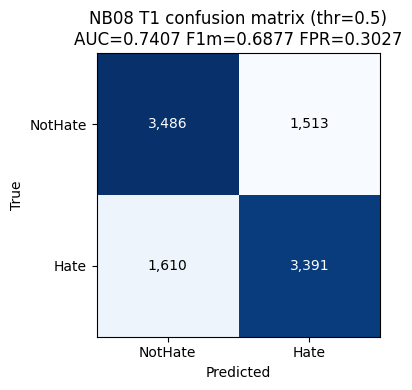

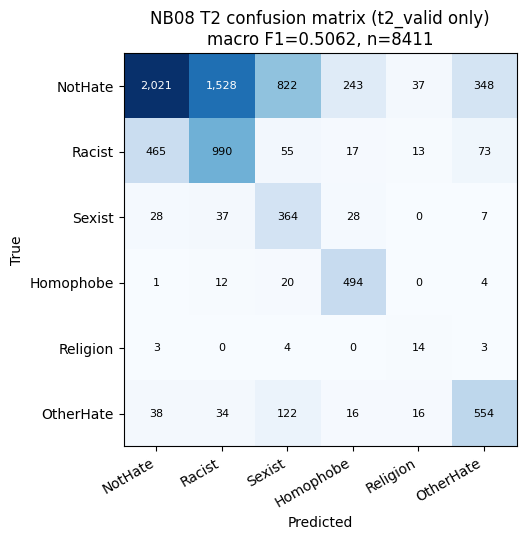

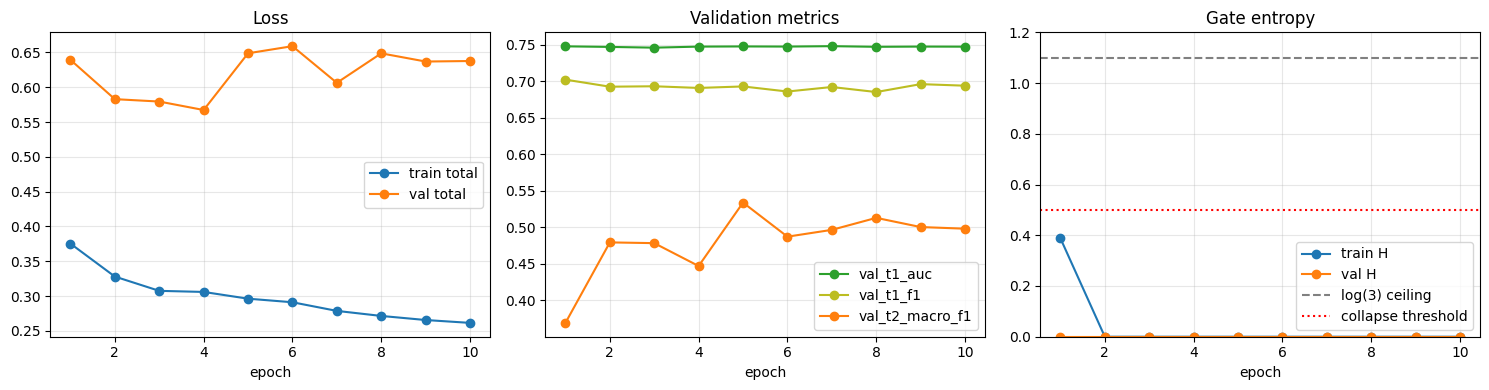

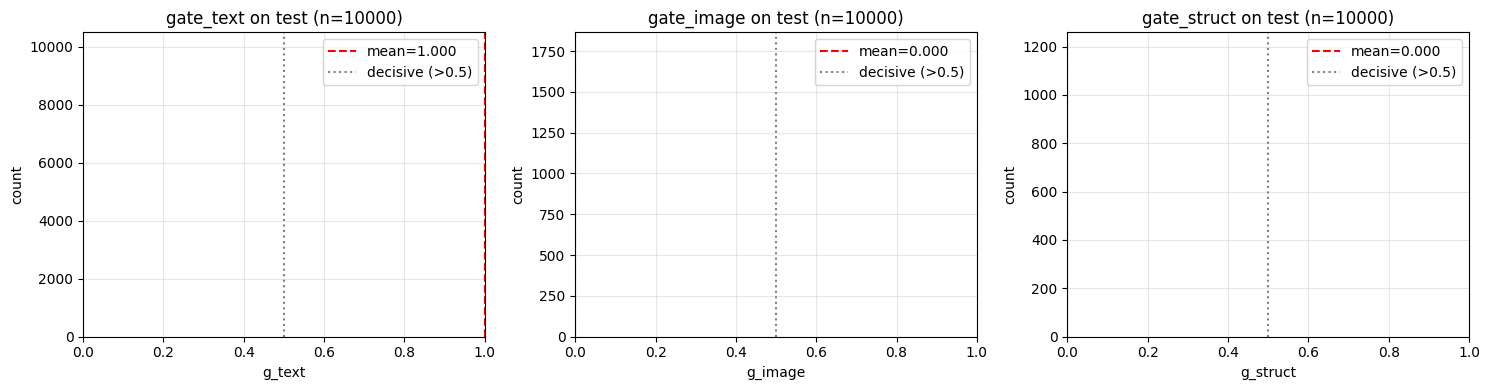

charts saved to outputs/: nb08b_t1_confusion_matrix.png, nb08b_t2_confusion_matrix.png, nb08b_training_curves.png, nb08b_gate_distribution.png


In [11]:
# Reload best checkpoint, run test-set evaluation, gate stats, save charts and per-sample gate weights.
rest = torch.load(BEST_DIR / 'mvp4_trainable.pt', map_location='cpu', weights_only=False)
model.struct_branch.load_state_dict(rest['struct_branch'])
model.cross_attn.load_state_dict(rest['cross_attn'])
model.cross_attn_ln.load_state_dict(rest['cross_attn_ln'])
model.gate.load_state_dict(rest['gate'])
model.proj_text.load_state_dict(rest['proj_text'])
model.proj_image.load_state_dict(rest['proj_image'])
model.proj_struct.load_state_dict(rest['proj_struct'])
model.head_t1.load_state_dict(rest['head_t1'])
model.head_t2.load_state_dict(rest['head_t2'])
model.to(device).eval()
print(f'reloaded best (epoch {rest["epoch"]}, val_t1_auc={rest["val_t1_auc"]:.4f}, '
      f'val_t2_macro_f1={rest["val_t2_macro_f1"]:.4f}, val_gate_H={rest["val_gate_H"]:.4f})')

t1_probs, t1_true = [], []
t2_preds, t2_true, t2_valid = [], [], []
all_gates, tweet_ids_out = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in test_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        pix  = batch['pixel_values'].to(device, non_blocking=True)
        stc  = batch['structured'].to(device, non_blocking=True)
        logit_t1, logits_t2, gates = model(ids, mask, pix, stc)
        t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        t1_true.append(batch['t1_label'].cpu().numpy())
        t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
        t2_true.append(batch['t2_label'].cpu().numpy())
        t2_valid.append(batch['t2_valid_mask'].cpu().numpy())
        all_gates.append(gates.float().cpu().numpy())
        tweet_ids_out.append(batch['tweet_id'].cpu().numpy())
all_t1_probs = np.concatenate(t1_probs); all_t1_true = np.concatenate(t1_true)
all_t2_preds = np.concatenate(t2_preds); all_t2_true = np.concatenate(t2_true); all_t2_valid = np.concatenate(t2_valid)
all_gates    = np.concatenate(all_gates, axis=0)        # (N_test, 3)
all_tweet_ids = np.concatenate(tweet_ids_out)            # (N_test,)
print(f'test predictions collected: t1_probs {all_t1_probs.shape}, gates {all_gates.shape}')

# --- T1 metrics at threshold 0.5 (balanced 50/50 test) ---
thr = HPARAMS['threshold']
all_t1_pred = (all_t1_probs >= thr).astype(int)
auc = roc_auc_score(all_t1_true, all_t1_probs)
f1m = f1_score(all_t1_true, all_t1_pred, average='macro')
pm  = precision_score(all_t1_true, all_t1_pred, average='macro', zero_division=0)
rm  = recall_score(all_t1_true, all_t1_pred, average='macro', zero_division=0)
cm  = confusion_matrix(all_t1_true, all_t1_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
fpr = fp / max(fp + tn, 1)
m_bal = {'AUC': float(auc), 'F1m': float(f1m), 'Pm': float(pm), 'Rm': float(rm), 'FPR': float(fpr),
         'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}
print(f'\n--- T1 BALANCED-TEST metrics (thr={thr}) ---')
for k, v in m_bal.items():
    if isinstance(v, float): print(f'  {k:<5} {v:.4f}')
    else:                    print(f'  {k:<5} {v}')

# --- T2 metrics on t2_valid=True only ---
mask = all_t2_valid.astype(bool)
if mask.sum() > 0:
    t2_macro = f1_score(all_t2_true[mask], all_t2_preds[mask], average='macro',
                         labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    per_class = f1_score(all_t2_true[mask], all_t2_preds[mask], average=None,
                          labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    cm_t2 = confusion_matrix(all_t2_true[mask], all_t2_preds[mask],
                              labels=list(range(HPARAMS['n_t2_classes'])))
    print(f'\n--- T2 metrics (t2_valid=True only, n={int(mask.sum())}) ---')
    print(f'  macro F1: {t2_macro:.4f}')
    t2_classes = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']
    for c, f1 in zip(t2_classes, per_class):
        print(f'  per-class F1  {c:<10} = {f1:.4f}')
else:
    t2_macro = float('nan'); per_class = np.full(HPARAMS['n_t2_classes'], np.nan); cm_t2 = None
    print('T2: no t2_valid=True rows in test set (unexpected)')

# --- GATE STATS on the test set ---
g_mean_test = all_gates.mean(axis=0)
g_std_test  = all_gates.std(axis=0)
gate_H_test = -(all_gates * np.log(all_gates + 1e-8)).sum(axis=-1)
print(f'\n--- TEST gate statistics ---')
print(f'  mean gate weights:  text={g_mean_test[0]:.4f}  image={g_mean_test[1]:.4f}  struct={g_mean_test[2]:.4f}')
print(f'  std  gate weights:  text={g_std_test[0]:.4f}  image={g_std_test[1]:.4f}  struct={g_std_test[2]:.4f}')
print(f'  mean gate entropy:  {gate_H_test.mean():.4f}  (max log(3)={float(np.log(3.0)):.4f})')
n_decisive = (all_gates > 0.5).sum(axis=0)
print(f'  modality-decisive samples (gate > 0.5):  text={int(n_decisive[0])}  image={int(n_decisive[1])}  struct={int(n_decisive[2])}  (of {len(all_gates)})')

# --- save per-sample gate weights for NB10 ---
np.save(MODEL_DIR / 'test_gates.npy',
        np.stack([all_tweet_ids.astype(np.int64),
                   all_gates[:, 0].astype(np.float32),
                   all_gates[:, 1].astype(np.float32),
                   all_gates[:, 2].astype(np.float32)], axis=1))
print(f'saved per-sample test gate weights -> {MODEL_DIR / "test_gates.npy"} (cols: tweet_id, g_text, g_image, g_struct)')

# --- CHARTS ---
import matplotlib.ticker as mtick

# T1 confusion matrix
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f'{v:,}', ha='center', va='center', color='black' if v < cm.max()/2 else 'white')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['NotHate', 'Hate']); ax.set_yticklabels(['NotHate', 'Hate'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'NB08 T1 confusion matrix (thr={thr})\nAUC={auc:.4f} F1m={f1m:.4f} FPR={fpr:.4f}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb08b_t1_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# T2 confusion matrix (valid only)
if cm_t2 is not None:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm_t2, cmap='Blues')
    t2_classes = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']
    for (i, j), v in np.ndenumerate(cm_t2):
        ax.text(j, i, f'{v:,}', ha='center', va='center',
                color='black' if v < cm_t2.max()/2 else 'white', fontsize=8)
    ax.set_xticks(range(HPARAMS['n_t2_classes'])); ax.set_yticks(range(HPARAMS['n_t2_classes']))
    ax.set_xticklabels(t2_classes, rotation=30, ha='right')
    ax.set_yticklabels(t2_classes)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'NB08 T2 confusion matrix (t2_valid only)\nmacro F1={t2_macro:.4f}, n={int(mask.sum())}')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'nb08b_t2_confusion_matrix.png', dpi=120, bbox_inches='tight')
    plt.show()

# Training curves: loss + val AUC + gate entropy over epochs
hist = history
ep = hist['epoch']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ep, hist['train_total'], label='train total', marker='o')
axes[0].plot(ep, hist['val_total'],   label='val total',   marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, hist['val_t1_auc'], label='val_t1_auc', marker='o', color='tab:green')
axes[1].plot(ep, hist['val_t1_f1'],  label='val_t1_f1',  marker='o', color='tab:olive')
axes[1].plot(ep, hist['val_t2_macro_f1'], label='val_t2_macro_f1', marker='o', color='tab:orange')
axes[1].set_title('Validation metrics'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ep, hist['train_gate_H'], label='train H', marker='o')
axes[2].plot(ep, hist['val_gate_H'],   label='val H',   marker='o')
axes[2].axhline(float(np.log(3.0)), color='gray', linestyle='--', label='log(3) ceiling')
axes[2].axhline(HPARAMS['collapse_threshold'], color='red', linestyle=':', label='collapse threshold')
axes[2].set_title('Gate entropy'); axes[2].set_xlabel('epoch'); axes[2].set_ylim(0, 1.2)
axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb08b_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Gate distribution histograms on test
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
branch_names = ['text', 'image', 'struct']
for j, (ax, name) in enumerate(zip(axes, branch_names)):
    ax.hist(all_gates[:, j], bins=40, color='tab:blue', alpha=0.85)
    ax.axvline(g_mean_test[j], color='red', linestyle='--', label=f'mean={g_mean_test[j]:.3f}')
    ax.axvline(0.5, color='gray', linestyle=':', label='decisive (>0.5)')
    ax.set_title(f'gate_{name} on test (n={len(all_gates)})')
    ax.set_xlabel(f'g_{name}'); ax.set_ylabel('count')
    ax.set_xlim(0, 1); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb08b_gate_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('charts saved to outputs/: nb08b_t1_confusion_matrix.png, nb08b_t2_confusion_matrix.png, '
      'nb08b_training_curves.png, nb08b_gate_distribution.png')


In [12]:
# Recalibrated T1 metrics - Bayes shift to deployment-time hate prior (val/test are 50/50; deployment ~22%).
prior_hate    = HPARAMS['prior_hate']
prior_nothate = HPARAMS['prior_nothate']

def recalibrate(p, ph=prior_hate, pn=prior_nothate):
    num = p * ph
    den = num + (1 - p) * pn
    return num / np.maximum(den, 1e-12)

v_probs, v_true = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in val_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        pix  = batch['pixel_values'].to(device, non_blocking=True)
        stc  = batch['structured'].to(device, non_blocking=True)
        logit_t1, _, _ = model(ids, mask, pix, stc)
        v_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        v_true.append(batch['t1_label'].cpu().numpy())
val_probs_arr = np.concatenate(v_probs); val_true_arr = np.concatenate(v_true)

test_probs_recal = recalibrate(all_t1_probs)
val_probs_recal  = recalibrate(val_probs_arr)

best_thr, best_thr_f1 = 0.5, -1.0
for t in np.linspace(0.01, 0.99, 99):
    pred = (val_probs_recal >= t).astype(int)
    fv = f1_score(val_true_arr, pred)
    if fv > best_thr_f1:
        best_thr_f1 = fv; best_thr = float(t)
print(f'F1-optimised threshold on RECALIBRATED VAL: {best_thr:.3f} (val F1={best_thr_f1:.4f})')
print(f'  recalibrated val prob range: [{val_probs_recal.min():.4f}, {val_probs_recal.max():.4f}], mean={val_probs_recal.mean():.4f}')
print(f'  recalibrated test prob range:[{test_probs_recal.min():.4f}, {test_probs_recal.max():.4f}], mean={test_probs_recal.mean():.4f}')

pred_recal = (test_probs_recal >= best_thr).astype(int)
auc_r = roc_auc_score(all_t1_true, test_probs_recal)  # AUC is invariant to monotonic transforms, sanity check
f1m_r = f1_score(all_t1_true, pred_recal, average='macro')
pm_r  = precision_score(all_t1_true, pred_recal, average='macro', zero_division=0)
rm_r  = recall_score(all_t1_true, pred_recal, average='macro', zero_division=0)
cm_r  = confusion_matrix(all_t1_true, pred_recal, labels=[0, 1])
tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
fpr_r = fp_r / max(fp_r + tn_r, 1)
m_rec = {'AUC': float(auc_r), 'F1m': float(f1m_r), 'Pm': float(pm_r), 'Rm': float(rm_r), 'FPR': float(fpr_r),
         'TN': int(tn_r), 'FP': int(fp_r), 'FN': int(fn_r), 'TP': int(tp_r), 'threshold': float(best_thr)}

print('\n--- BALANCED-TEST  vs  RECALIBRATED-TEST  T1 metrics ---')
print(f'  {"":<7} {"balanced (thr=0.5)":>22} {"recalibrated (thr opt)":>24}')
for k in ['AUC', 'F1m', 'Pm', 'Rm', 'FPR']:
    print(f'  {k:<7} {m_bal[k]:>22.4f} {m_rec[k]:>24.4f}')
print(f'  CM bal: TN={m_bal["TN"]} FP={m_bal["FP"]} FN={m_bal["FN"]} TP={m_bal["TP"]}')
print(f'  CM rec: TN={m_rec["TN"]} FP={m_rec["FP"]} FN={m_rec["FN"]} TP={m_rec["TP"]}   '
      f'(threshold used on recalibrated probs: {best_thr:.3f})')


F1-optimised threshold on RECALIBRATED VAL: 0.210 (val F1=0.7107)
  recalibrated val prob range: [0.0341, 0.4709], mean=0.2577
  recalibrated test prob range:[0.0333, 0.4825], mean=0.2591

--- BALANCED-TEST  vs  RECALIBRATED-TEST  T1 metrics ---
              balanced (thr=0.5)   recalibrated (thr opt)
  AUC                     0.7407                   0.7407
  F1m                     0.6877                   0.6732
  Pm                      0.6878                   0.6843
  Rm                      0.6877                   0.6766
  FPR                     0.3027                   0.4257
  CM bal: TN=3486 FP=1513 FN=1610 TP=3391
  CM rec: TN=2871 FP=2128 FN=1106 TP=3895   (threshold used on recalibrated probs: 0.210)


In [13]:
# Final comparison vs MVP 1 / 2 / 3, verdict, and save final artifacts.
mvp1      = {'AUC': 0.7431, 'F1m': 0.6855, 'FPR': 0.2667, 'label': 'MVP 1 (text-only)'}
mvp2      = {'AUC': 0.7411, 'F1m': 0.6892, 'FPR': 0.3041, 'label': 'MVP 2 (T+I naive)'}
mvp3      = {'AUC': 0.7406, 'F1m': 0.6905, 'FPR': 0.3361, 'label': 'MVP 3 (T+I+S naive)'}
mvp4_orig = {'AUC': 0.7400, 'F1m': 0.6888, 'FPR': 0.3071, 'label': 'MVP 4 (orig, ent_w=0.05, 5ep)'}
this      = {'AUC': m_bal['AUC'], 'F1m': m_bal['F1m'], 'FPR': m_bal['FPR'], 'label': 'MVP 4-B (ent_w=0.01, 10ep)'}

def delta(a, b):
    return a - b
rows = [mvp1, mvp2, mvp3, mvp4_orig, this]
print('=== MVP 1 / MVP 2 / MVP 3 / MVP 4 (orig) / MVP 4-B (ent_w=0.01, 10ep) comparison (balanced 50/50 test, thr=0.5) ===')
print(f'  {"":<26} {"AUC":>8} {"F1m":>8} {"FPR":>8}')
for r in rows:
    print(f'  {r["label"]:<26} {r["AUC"]:>8.4f} {r["F1m"]:>8.4f} {r["FPR"]:>8.4f}')

print('\n  Deltas (MVP 4 - baseline):')
for base in [mvp1, mvp2, mvp3, mvp4_orig]:
    d_auc = delta(this['AUC'], base['AUC'])
    d_f1m = delta(this['F1m'], base['F1m'])
    d_fpr = delta(this['FPR'], base['FPR'])
    print(f'    vs {base["label"]:<24}  d_AUC={d_auc:+.4f}  d_F1m={d_f1m:+.4f}  d_FPR={d_fpr:+.4f}')

# Verdict
NOISE = 0.005
auc_lift_vs_best = this['AUC'] - max(mvp1['AUC'], mvp2['AUC'], mvp3['AUC'])
fpr_drop_vs_best = min(mvp2['FPR'], mvp3['FPR']) - this['FPR']  # positive = drop is good

auc_pass = auc_lift_vs_best > NOISE
fpr_pass = this['FPR'] < mvp2['FPR'] - NOISE

print(f'\n  AUC lift over best baseline: {auc_lift_vs_best:+.4f}  -> {"PASS" if auc_pass else "fail"} (need > +{NOISE:.3f})')
print(f'  FPR drop vs MVP 2:           {fpr_drop_vs_best:+.4f}  -> {"PASS" if fpr_pass else "fail"} (need < MVP 2 by {NOISE:.3f})')

if auc_pass and fpr_pass:
    verdict = ('PRIMARY HYPOTHESIS CONFIRMED. Gated cross-modal attention with entropy regularisation '
                'breaks the ~0.74 AUC ceiling and reduces FPR below naive concat. The multimodal '
                'contribution of the thesis is supported.')
elif auc_pass and not fpr_pass:
    verdict = ('PARTIAL CONFIRMATION. AUC lifts above the naive baselines but FPR does not improve over '
                'MVP 2. Multimodal signal is being recovered but the gate is not yet suppressing '
                'false positives - inspect per-class FPR and consider raising entropy_weight.')
elif fpr_pass and not auc_pass:
    verdict = ('PARTIAL CONFIRMATION. FPR drops below MVP 2 but AUC does not exceed the naive baselines '
                'by a meaningful margin. The gate is acting conservatively without unlocking new signal.')
else:
    verdict = ('PRIMARY HYPOTHESIS NOT SUPPORTED ON THIS RUN. Gated attention did not beat the naive '
                'baselines on either AUC or FPR. Inspect gate entropy trajectory and per-branch usage; '
                'consider tuning entropy_weight, fusion_dim, or unfreezing select layers.')
print(f'\n  VERDICT: {verdict}')

# Final gate usage commentary
g_mean = g_mean_test  # from CELL 12
gate_uses_all = (g_mean > 0.10).all()
gate_dom = ['text', 'image', 'struct'][int(np.argmax(g_mean))]
print(f'\n  Final mean gate distribution: text={g_mean[0]:.3f} image={g_mean[1]:.3f} struct={g_mean[2]:.3f}')
print(f'  All three modalities active (> 0.10)? {bool(gate_uses_all)}')
print(f'  Dominant branch: {gate_dom} (g={max(g_mean):.3f})')
print(f'  Mean test gate entropy: {gate_H_test.mean():.4f}  (log(3)={float(np.log(3.0)):.4f})')

# Save final artifacts
shutil.copy(BEST_DIR / 'mvp4_trainable.pt', MODEL_DIR / 'mvp4_trainable.pt')
shutil.copy(BEST_DIR / 'standardisation_stats.json', MODEL_DIR / 'standardisation_stats.json')

with open(MODEL_DIR / 'hparams.json', 'w') as f:
    json.dump({k: v for k, v in HPARAMS.items() if not k.startswith('_')}, f, indent=2)
with open(MODEL_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

metrics_payload = {
    'run_label': 'mvp4_gated_fusion_ent01',
    'best_epoch': int(best_epoch),
    'best_val_t1_auc': float(best_t1_auc),
    'best_val_t2_macro_f1': float(history['val_t2_macro_f1'][best_epoch - 1]) if best_epoch >= 1 else None,
    't1_pos_weight': float(pos_weight_value),
    't1_thresholds': {'balanced_headline': 0.5, 'recal_f1_optimised_on_recal_val': float(best_thr)},
    'priors_for_recalibration': {'hate': prior_hate, 'nothate': prior_nothate},
    't1_balanced_test_thr_0.5':       m_bal,
    't1_recalibrated_test_thr_opt':   m_rec,
    't2_test_macro_f1_valid_only':    float(t2_macro),
    't2_test_n_valid':                int(mask.sum()),
    'loss_weights': {'t1': HPARAMS['t1_weight'], 't2': HPARAMS['t2_weight'], 'entropy': HPARAMS['entropy_weight']},
    'comparison': {
        'mvp1': mvp1, 'mvp2': mvp2, 'mvp3': mvp3, 'mvp4_orig': mvp4_orig, 'mvp4b': this,
        'auc_lift_vs_best_baseline': float(auc_lift_vs_best),
        'fpr_drop_vs_mvp2': float(fpr_drop_vs_best),
        'auc_pass': bool(auc_pass), 'fpr_pass': bool(fpr_pass),
        'verdict': verdict,
    },
}
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

final_gate_stats = {
    'mean': {'text': float(g_mean_test[0]), 'image': float(g_mean_test[1]), 'struct': float(g_mean_test[2])},
    'std':  {'text': float(g_std_test[0]),  'image': float(g_std_test[1]),  'struct': float(g_std_test[2])},
    'mean_entropy_test': float(gate_H_test.mean()),
    'max_entropy_log3':  float(np.log(3.0)),
    'decisive_count_gt_0.5': {'text': int(n_decisive[0]), 'image': int(n_decisive[1]), 'struct': int(n_decisive[2])},
    'n_test': int(len(all_gates)),
}
with open(MODEL_DIR / 'final_gate_stats.json', 'w') as f:
    json.dump(final_gate_stats, f, indent=2)

print(f'\nartifacts saved to {MODEL_DIR}:')
for p in sorted(MODEL_DIR.iterdir()):
    sz_kb = p.stat().st_size / 1024
    print(f'  {p.name:<35} {sz_kb:>10.1f} KB')
print(f'best checkpoint:        {BEST_DIR / "mvp4_trainable.pt"}')
print(f'per-sample test gates:  {MODEL_DIR / "test_gates.npy"}  (for NB10)')
print(f'\nDONE.')


=== MVP 1 / MVP 2 / MVP 3 / MVP 4 (orig) / MVP 4-B (ent_w=0.01, 10ep) comparison (balanced 50/50 test, thr=0.5) ===
                                  AUC      F1m      FPR
  MVP 1 (text-only)            0.7431   0.6855   0.2667
  MVP 2 (T+I naive)            0.7411   0.6892   0.3041
  MVP 3 (T+I+S naive)          0.7406   0.6905   0.3361
  MVP 4 (orig, ent_w=0.05, 5ep)   0.7400   0.6888   0.3071
  MVP 4-B (ent_w=0.01, 10ep)   0.7407   0.6877   0.3027

  Deltas (MVP 4 - baseline):
    vs MVP 1 (text-only)         d_AUC=-0.0024  d_F1m=+0.0022  d_FPR=+0.0360
    vs MVP 2 (T+I naive)         d_AUC=-0.0004  d_F1m=-0.0015  d_FPR=-0.0014
    vs MVP 3 (T+I+S naive)       d_AUC=+0.0001  d_F1m=-0.0028  d_FPR=-0.0334
    vs MVP 4 (orig, ent_w=0.05, 5ep)  d_AUC=+0.0007  d_F1m=-0.0011  d_FPR=-0.0044

  AUC lift over best baseline: -0.0024  -> fail (need > +0.005)
  FPR drop vs MVP 2:           +0.0014  -> fail (need < MVP 2 by 0.005)

  VERDICT: PRIMARY HYPOTHESIS NOT SUPPORTED ON THIS RUN. Gated a